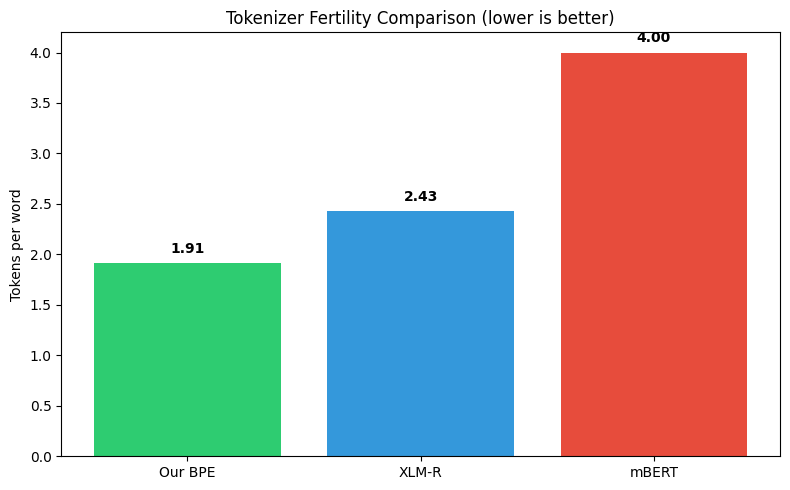

In [2]:
import json
import matplotlib.pyplot as plt

# Load tokenizer analysis results
with open("../eval/fertility_analysis.json", "w") as f:
    pass  # We'll create this from the analyze script output

# Tokenizer fertility comparison
tokenizers = ['Our BPE', 'XLM-R', 'mBERT']
fertilities = [1.91, 2.43, 4.00]

plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = plt.bar(tokenizers, fertilities, color=colors)
plt.ylabel("Tokens per word")
plt.title("Tokenizer Fertility Comparison (lower is better)")

for bar, val in zip(bars, fertilities):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
from transformers import AutoTokenizer
import os

# Use local paths with ./ prefix or absolute paths
our_tok = AutoTokenizer.from_pretrained("../tokenizer")
xlmr_tok = AutoTokenizer.from_pretrained("xlm-roberta-base")

sentences = [
    "ನಾನು ಇಂದು ಬೆಂಗಳೂರಿಗೆ ಹೋಗುತ್ತಿದ್ದೇನೆ",
    "ಕನ್ನಡ ಭಾಷೆಯ ಸೌಂದರ್ಯ ಅದ್ಭುತವಾಗಿದೆ",
    "ಭಾರತೀಯ ಸಂಸ್ಕೃತಿ ವಿಶ್ವದಲ್ಲಿಯೇ ಶ್ರೇಷ್ಠ",
]

for sent in sentences:
    our_tokens = our_tok.tokenize(sent)
    xlmr_tokens = xlmr_tok.tokenize(sent)
    print(f"Text: {sent}")
    print(f"  Our BPE ({len(our_tokens)}): {our_tokens}")
    print(f"  XLM-R  ({len(xlmr_tokens)}): {xlmr_tokens}")
    print()

Text: ನಾನು ಇಂದು ಬೆಂಗಳೂರಿಗೆ ಹೋಗುತ್ತಿದ್ದೇನೆ
  Our BPE (5): ['ನಾನು', 'ಇಂದು', 'ಬೆಂಗಳೂರಿಗೆ', 'ಹೋಗ', 'ುತ್ತಿದ್ದೇನೆ']
  XLM-R  (7): ['▁ನಾನು', '▁ಇಂದು', '▁ಬೆಂಗಳೂರ', 'ಿಗೆ', '▁ಹೋಗ', 'ುತ್ತ', 'ಿದ್ದೇನೆ']

Text: ಕನ್ನಡ ಭಾಷೆಯ ಸೌಂದರ್ಯ ಅದ್ಭುತವಾಗಿದೆ
  Our BPE (5): ['ಕನ್ನಡ', 'ಭಾಷೆಯ', 'ಸೌಂದರ್ಯ', 'ಅದ್ಭುತ', 'ವಾಗಿದೆ']
  XLM-R  (6): ['▁ಕನ್ನಡ', '▁ಭಾಷೆ', 'ಯ', '▁ಸೌಂದರ್ಯ', '▁ಅದ್ಭುತ', 'ವಾಗಿದೆ']

Text: ಭಾರತೀಯ ಸಂಸ್ಕೃತಿ ವಿಶ್ವದಲ್ಲಿಯೇ ಶ್ರೇಷ್ಠ
  Our BPE (5): ['ಭಾರತೀಯ', 'ಸಂಸ್ಕೃತಿ', 'ವಿಶ್ವ', 'ದಲ್ಲಿಯೇ', 'ಶ್ರೇಷ್ಠ']
  XLM-R  (8): ['▁ಭಾರತೀಯ', '▁ಸಂಸ್ಕೃತಿ', '▁ವಿಶ್ವ', 'ದಲ್ಲಿ', 'ಯೇ', '▁ಶ್ರ', 'ೇ', 'ಷ್ಠ']

